# Simulator & Controller: Bagaimana Algoritma Strategi "Berbicara" dengan Digital Twin

Dua notebook lain sudah menjawab pertanyaan yang berbeda: `Digital_Twin_Construction.ipynb` menjelaskan
bagaimana FISIKANYA dibangun (track/cuaca/kendaraan/powertrain/`simulate.py`), berhenti tepat sebelum
strategi apapun ikut campur. `SEM_Digital_Twin_Demo.ipynb` menunjukkan HASIL AKHIR tiap strategi (skor,
liter H2). Notebook ini mengisi celah di ANTARA keduanya: **bagaimana persisnya tiap algoritma strategi
(DP/GA/PSO/CMA-ES/Fuzzy/MPC) benar-benar memanggil `simulate.py`** -- lewat pintu masuk yang mana, berapa
kali, dan kenapa arsitekturnya berbeda-beda per algoritma alih-alih satu pola seragam.

**Temuan inti (dikonfirmasi langsung dari source, bukan diasumsikan):** ada TIGA pola interaksi yang
sama sekali berbeda, bukan satu:

1. **Batch/rencana-di-muka** (GA, PSO, CMA-ES, Fuzzy) -- putuskan kecepatan target untuk SELURUH lap
   di muka, panggil `simulate.simulate()` SATU KALI untuk mengevaluasinya, ulangi untuk kandidat
   berikutnya.
2. **Grid dynamic programming** (DP) -- TIDAK PERNAH memanggil `simulate.py` untuk perhitungan intinya
   sama sekali; ia menulis ulang fisika `vehicle.py`/`powertrain.py` sendiri di atas grid
   (jarak x kecepatan) miliknya sendiri, demi kecepatan komputasi.
3. **Receding-horizon** (MPC) -- memanggil `simulate.step()` (satu langkah fisika, bukan satu lap
   penuh) BERKALI-KALI untuk setiap SATU keputusan nyata: dulu untuk membayangkan beberapa kandidat masa
   depan, baru sekali lagi untuk benar-benar melangkah, lalu mengulang proses itu di titik berikutnya.

Software/library: sama seperti notebook lain (Python + NumPy + Pandas + Matplotlib), plus `pymoo`
(GA/PSO/CMA-ES, dipakai `optimize_ga/pso/cma.py`, tidak diimpor ulang di sini -- cukup dijelaskan
antarmukanya) dan `scipy` tidak dibutuhkan di notebook ini.

In [1]:
import os, sys, math, time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

from digital_twin import config
from digital_twin import track as track_mod
from digital_twin import weather as weather_mod
from digital_twin import powertrain
from digital_twin import simulate as sim_mod
from digital_twin import telemetry as telemetry_mod
from digital_twin import optimize_dp
from digital_twin import mpc as mpc_mod

_rc = {
    'figure.facecolor': '#0d1117', 'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d', 'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e', 'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9', 'grid.color':       '#21262d',
    'grid.linestyle':   '--',      'grid.alpha':        0.6,
    'legend.facecolor': '#161b22', 'legend.edgecolor': '#30363d',
}
plt.rcParams.update(_rc)

scenario = weather_mod.SCENARIOS["typical_january"]
motors = powertrain.load_motors()
fc = powertrain.load_fuel_cells()[config.DEFAULT_FC_NAME]
accel_motor = motors[config.ACCEL_MOTOR_NAME]
cruise_motor = motors[config.CRUISE_MOTOR_NAME]

profile_1lap = track_mod.build_racing_line_profile(save=False)
full_track = sim_mod.build_full_attempt_track(profile_1lap)

print("Library dimuat. Working directory:", os.getcwd())
print(f"Track: {full_track['s_m'].iloc[-1]/1000:.2f} km, {len(full_track)} titik ({config.TOTAL_LAPS} lap)")

powertrain.load_motors(): excluding ['Mitsubishi M2096D-III'] -- exceeds 60.0V vehicle electrical limit (technical-inspection risk)
Library dimuat. Working directory: C:\Users\Terano\Downloads\Final_Project
Track: 14.50 km, 2936 titik (4 lap)


## 0. Bagaimana `simulate()` Bekerja: Loop Fisika Per-Titik

Sebelum membahas bagaimana algoritma strategi (DP/GA/PSO/CMA-ES/Fuzzy/MPC) MEMANGGIL `simulate.py`,
lebih dulu perlu jelas apa yang sebenarnya terjadi DI DALAM satu panggilan `simulate.simulate()`. Fungsi
ini menerima satu `full_track` (rangkaian titik jarak dengan grade/heading/radius tikungan/status stop
wajib per titik) dan sebuah `scenario` cuaca, lalu mengembalikan telemetri lengkap lewat SATU loop
`for i in range(n-1)` yang berjalan dari titik pertama sampai titik terakhir track. Rumusnya dari
`vehicle.py`/`powertrain.py`, `simulate.py` yang mengorkestrasi urutannya -- diagram di bawah memetakan
persis urutan langkah yang dikerjakan SETIAP iterasi `i`, plus satu lapisan PASCA-loop (hybrid
FC/supercap) yang bukan bagian dari loop per-titik itu sendiri.

Delapan langkah loop ini persis yang di-refactor jadi `simulate.step()` (Bagian 2 di bawah) supaya bisa
dipanggil satu-langkah-satu-langkah oleh MPC -- `step()` TIDAK menjalankan pasca-proses hybrid (itu
level-lap, bukan level-langkah), jadi output `step()` selalu pra-hybrid.

In [2]:
# Demonstrasi konkret: SATU panggilan simulate() gaya "crude" (tanpa v_target/v_coast --
# selalu kejar plafon kecepatan v_ceiling), dua-motor mode "rule", supaya delapan langkah
# di atas kelihatan sebagai angka nyata, bukan cuma teori.
t0 = time.time()
tel_intro = sim_mod.simulate(full_track, scenario, accel_motor=accel_motor, cruise_motor=cruise_motor,
                              fc=fc, motor_select_mode="rule")
elapsed_intro = time.time() - t0
print(f"1x simulate() (gaya crude, {len(full_track)} titik, {config.TOTAL_LAPS} lap): {elapsed_intro:.2f} s\n")

# Ambil titik dengan gaya cornering TERBESAR -- tikungan paling tajam di track --
# supaya semua gaya (drag/roll/grade/cornering) benar-benar tidak nol, bukan jalan lurus datar.
idx = int(tel_intro["f_cornering_n"].idxmax())
row = tel_intro.iloc[idx]

print(f"=== Titik contoh: index {idx}, jarak {row['distance_km']:.3f} km (lap {int(row['lap'])}) ===")
print(f"input track    : grade={row['grade_pct']:.2f} %, r_min={row['r_min_m']:.1f} m, heading={row['heading_deg']:.1f} deg")
print(f"(1) kecepatan  : v={row['v_kmh']:.1f} km/h, a_realisasi={row['a_ms2']:.3f} m/s^2, plafon v_ceiling={row['v_ceiling_kmh']:.1f} km/h")
print(f"(2) gaya hambat: drag={row['f_drag_n']:.1f} N | roll={row['f_roll_n']:.1f} N | grade={row['f_grade_n']:.1f} N | cornering={row['f_cornering_n']:.1f} N")
print(f"(3) traksi     : f_traction={row['f_traction_n']:.1f} N -> daya roda p_wheel={row['p_wheel_w']:.0f} W")
print(f"(4)(5) motor   : {row['active_motor']} aktif | motor_state={row['motor_state']} | motor_clipped(power-limited)={bool(row['motor_clipped'])}")
print(f"(7) listrik     : p_motor_elec={row['p_motor_elec_w']:.0f} W -> p_fc_elec (permintaan sesaat)={row['p_fc_elec_w']:.0f} W")
print(f"H2 (pasca-hybrid): h2_flow={row['h2_flow_m3_s']*1e6:.3f} mL/s | H2 kumulatif sejauh ini={row['h2_cumulative_m3']*1000:.3f} L")
if row["h2_flow_m3_s"] == 0.0 and row["p_fc_elec_w"] > 0:
    print("  (h2_flow=0 walau p_fc_elec>0 di titik INI itu wajar, bukan bug -- lihat catatan hybrid")
    print("   FC/supercap di atas: FC sedang mati, supercap menanggung beban sesaat.)")

1x simulate() (gaya crude, 2936 titik, 4 lap): 0.83 s

=== Titik contoh: index 522, jarak 2.570 km (lap 1) ===
input track    : grade=0.02 %, r_min=33.2 m, heading=234.4 deg
(1) kecepatan  : v=28.6 km/h, a_realisasi=-0.049 m/s^2, plafon v_ceiling=30.0 km/h
(2) gaya hambat: drag=1.9 N | roll=6.2 N | grade=0.3 N | cornering=15.0 N
(3) traksi     : f_traction=15.7 N -> daya roda p_wheel=125 W
(4)(5) motor   : BG 42x30 dCore aktif | motor_state=accel | motor_clipped(power-limited)=True
(7) listrik     : p_motor_elec=284 W -> p_fc_elec (permintaan sesaat)=294 W
H2 (pasca-hybrid): h2_flow=0.000 mL/s | H2 kumulatif sejauh ini=13.487 L
  (h2_flow=0 walau p_fc_elec>0 di titik INI itu wajar, bukan bug -- lihat catatan hybrid
   FC/supercap di atas: FC sedang mati, supercap menanggung beban sesaat.)


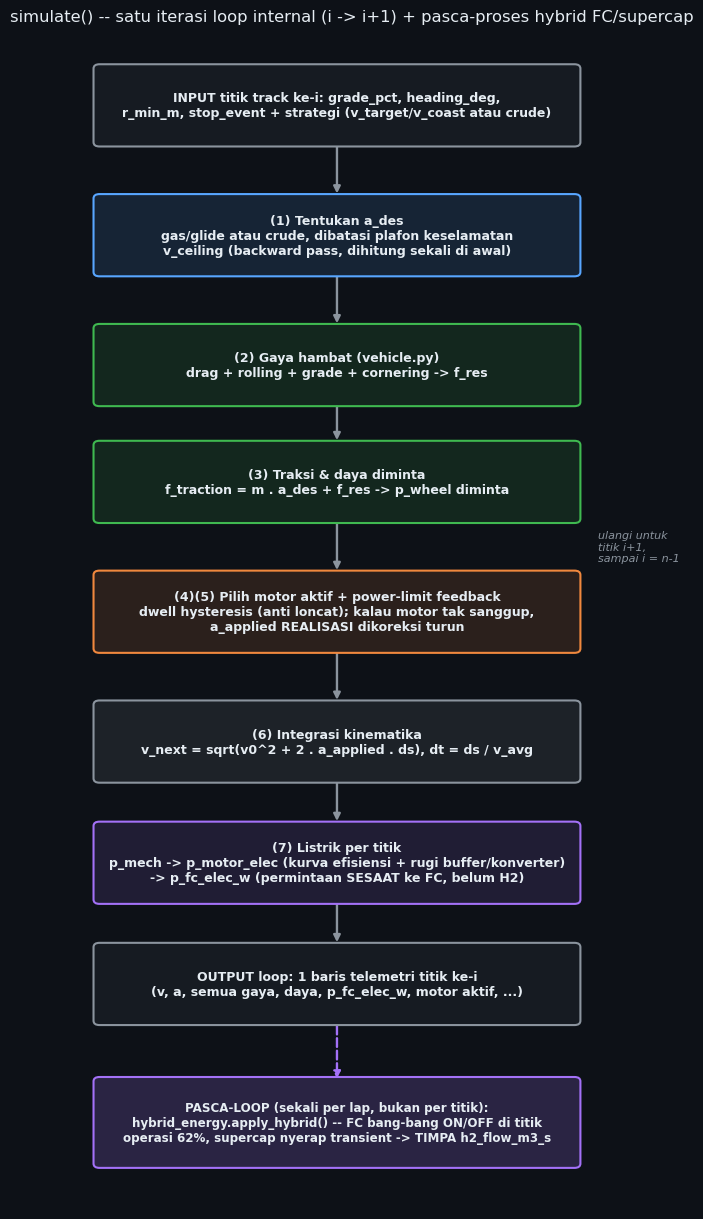

Catatan warna: biru=keputusan strategi (a_des), hijau=fisika gaya & traksi, oranye=motor & power-limit,
ungu=listrik & H2 (garis putus-putus = pasca-proses SEKALI PER LAP, bukan bagian loop per-titik).
Bagian 1 di bawah menunjukkan bagian pipeline mana yang benar-benar disentuh/dilewati tiap kategori
algoritma strategi (DP melewati langkah 1-6 lewat lookup table sendiri; MPC memanggil PERSIS
langkah 1-7 ini via step(), satu per satu -- step() TIDAK menjalankan pasca-proses hybrid).


In [3]:
fig, ax = plt.subplots(figsize=(6.8, 12.3))
ax.set_xlim(0, 10.5)
ax.set_ylim(0, 27)
ax.axis("off")
_box_style = dict(boxstyle="round,pad=0.10", linewidth=1.5)

def _pbox(y, text, bg, ec, fontsize=9.0, h=1.7):
    b = mpatches.FancyBboxPatch((1.0, y - h / 2), 8.0, h, facecolor=bg, edgecolor=ec, **_box_style, zorder=3)
    ax.add_patch(b)
    ax.text(5.0, y, text, ha="center", va="center", fontsize=fontsize, color="#e6edf3", fontweight="bold", zorder=4)

def _parrow(y0, y1, color="#8b949e", style="-"):
    ax.annotate("", xy=(5.0, y1), xytext=(5.0, y0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=1.7, linestyle=style, shrinkA=2, shrinkB=2), zorder=2)

loop_steps = [
    (25.5, "INPUT titik track ke-i: grade_pct, heading_deg,\nr_min_m, stop_event + strategi (v_target/v_coast atau crude)", "#161b22", "#8b949e"),
    (22.5, "(1) Tentukan a_des\ngas/glide atau crude, dibatasi plafon keselamatan\nv_ceiling (backward pass, dihitung sekali di awal)", "#58a6ff22", "#58a6ff"),
    (19.5, "(2) Gaya hambat (vehicle.py)\ndrag + rolling + grade + cornering -> f_res", "#3fb95022", "#3fb950"),
    (16.8, "(3) Traksi & daya diminta\nf_traction = m . a_des + f_res -> p_wheel diminta", "#3fb95022", "#3fb950"),
    (13.8, "(4)(5) Pilih motor aktif + power-limit feedback\ndwell hysteresis (anti loncat); kalau motor tak sanggup,\na_applied REALISASI dikoreksi turun", "#f0883e22", "#f0883e"),
    (10.8, "(6) Integrasi kinematika\nv_next = sqrt(v0^2 + 2 . a_applied . ds), dt = ds / v_avg", "#8b949e22", "#8b949e"),
    (8.0, "(7) Listrik per titik\np_mech -> p_motor_elec (kurva efisiensi + rugi buffer/konverter)\n-> p_fc_elec_w (permintaan SESAAT ke FC, belum H2)", "#a371f722", "#a371f7"),
    (5.2, "OUTPUT loop: 1 baris telemetri titik ke-i\n(v, a, semua gaya, daya, p_fc_elec_w, motor aktif, ...)", "#161b22", "#8b949e"),
]
for y, text, bg, ec in loop_steps:
    _pbox(y, text, bg, ec)
for (y0, *_), (y1, *_) in zip(loop_steps, loop_steps[1:]):
    _parrow(y0 - 0.9, y1 + 0.9)

ax.text(9.4, 15.3, "ulangi untuk\ntitik i+1,\nsampai i = n-1", ha="left", va="center", fontsize=8,
        color="#8b949e", style="italic")

# post-loop hybrid step, visually separated below the main loop (NOT part of it)
_pbox(2.0, "PASCA-LOOP (sekali per lap, bukan per titik):\nhybrid_energy.apply_hybrid() -- FC bang-bang ON/OFF di titik\noperasi 62%, supercap nyerap transient -> TIMPA h2_flow_m3_s",
      "#a371f733", "#a371f7", fontsize=8.6, h=1.9)
_parrow(5.2 - 0.9, 2.0 + 0.95, color="#a371f7", style="--")

ax.set_title("simulate() -- satu iterasi loop internal (i -> i+1) + pasca-proses hybrid FC/supercap",
              fontsize=11.8, color="#e6edf3", pad=14)
plt.tight_layout()
plt.savefig("assets/plot_ctrl_simulate_pipeline.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("Catatan warna: biru=keputusan strategi (a_des), hijau=fisika gaya & traksi, oranye=motor & power-limit,")
print("ungu=listrik & H2 (garis putus-putus = pasca-proses SEKALI PER LAP, bukan bagian loop per-titik).")
print("Bagian 1 di bawah menunjukkan bagian pipeline mana yang benar-benar disentuh/dilewati tiap kategori")
print("algoritma strategi (DP melewati langkah 1-6 lewat lookup table sendiri; MPC memanggil PERSIS")
print("langkah 1-7 ini via step(), satu per satu -- step() TIDAK menjalankan pasca-proses hybrid).")

## 1. Peta Tiga Pola Interaksi

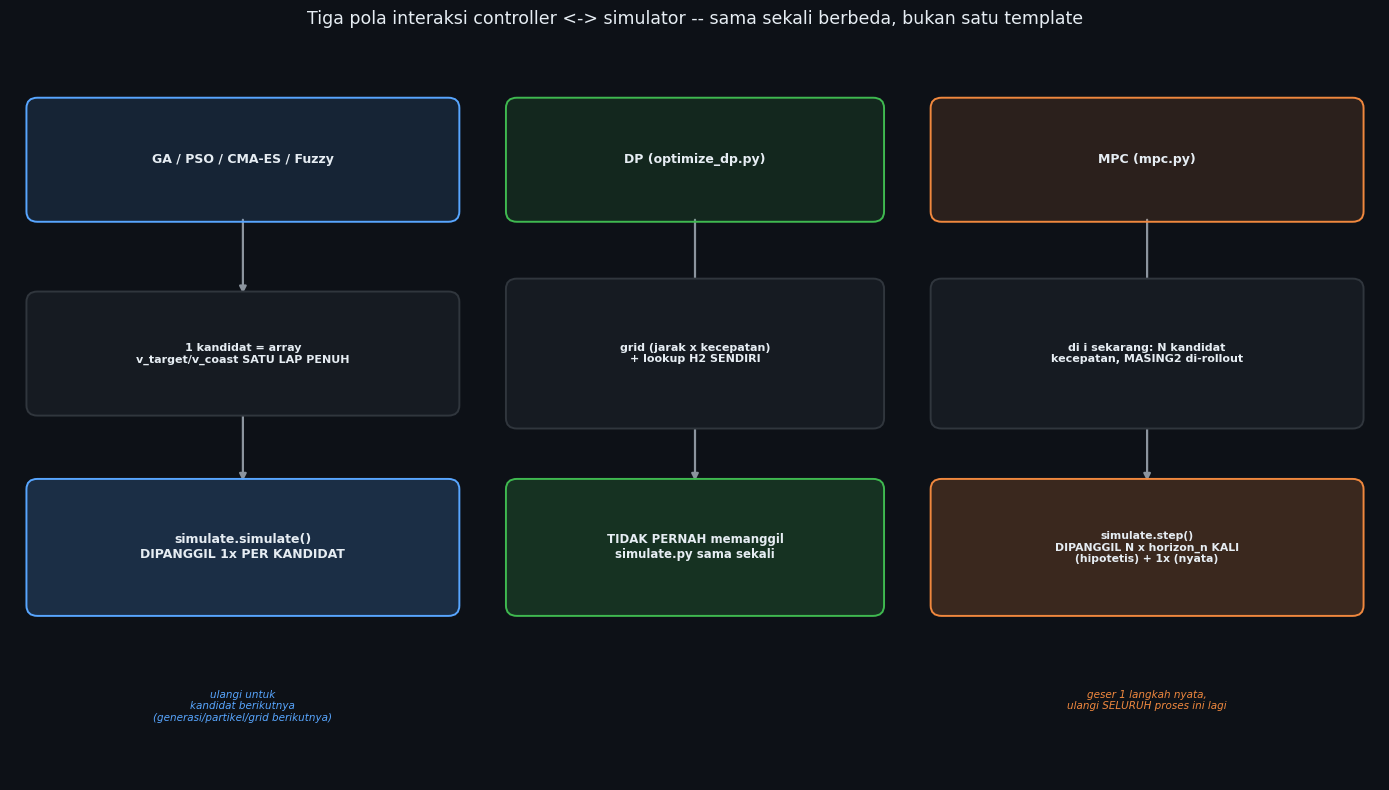

In [4]:
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 10)
ax.set_ylim(3.2, 8.9)
ax.axis("off")
box_style = dict(boxstyle="round,pad=0.08", linewidth=1.4)

def draw_box(x, y, w, h, text, fc, ec, fontsize=9):
    b = mpatches.FancyBboxPatch((x - w / 2, y - h / 2), w, h, facecolor=fc, edgecolor=ec,
                                 **box_style, zorder=3)
    ax.add_patch(b)
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize, color="#e6edf3",
            fontweight="bold", zorder=4)

def arrow(x0, y0, x1, y1, color="#8b949e", label=None, style="-"):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=1.6, linestyle=style, shrinkA=6, shrinkB=6), zorder=2)
    if label:
        ax.text((x0 + x1) / 2, (y0 + y1) / 2 + 0.15, label, ha="center", fontsize=7.5, color=color)

# Category 1: batch planners
draw_box(1.7, 8.0, 3.0, 0.8, "GA / PSO / CMA-ES / Fuzzy", "#58a6ff22", "#58a6ff")
draw_box(1.7, 6.5, 3.0, 0.8, "1 kandidat = array\nv_target/v_coast SATU LAP PENUH", "#161b22", "#30363d", fontsize=8)
draw_box(1.7, 5.0, 3.0, 0.9, "simulate.simulate()\nDIPANGGIL 1x PER KANDIDAT", "#58a6ff33", "#58a6ff")
arrow(1.7, 7.6, 1.7, 6.9)
arrow(1.7, 6.1, 1.7, 5.45)
ax.text(1.7, 3.9, "ulangi untuk\nkandidat berikutnya\n(generasi/partikel/grid berikutnya)",
        ha="center", fontsize=7.5, color="#58a6ff", style="italic", va="top")

# Category 2: DP
draw_box(5.0, 8.0, 2.6, 0.8, "DP (optimize_dp.py)", "#3fb95022", "#3fb950")
draw_box(5.0, 6.5, 2.6, 1.0, "grid (jarak x kecepatan)\n+ lookup H2 SENDIRI", "#161b22", "#30363d", fontsize=8)
draw_box(5.0, 5.0, 2.6, 0.9, "TIDAK PERNAH memanggil\nsimulate.py sama sekali", "#3fb95033", "#3fb950", fontsize=8.5)
arrow(5.0, 7.6, 5.0, 6.9)
arrow(5.0, 6.1, 5.0, 5.45)

# Category 3: MPC
draw_box(8.3, 8.0, 3.0, 0.8, "MPC (mpc.py)", "#f0883e22", "#f0883e")
draw_box(8.3, 6.5, 3.0, 1.0, "di i sekarang: N kandidat\nkecepatan, MASING2 di-rollout", "#161b22", "#30363d", fontsize=8)
draw_box(8.3, 5.0, 3.0, 0.9, "simulate.step()\nDIPANGGIL N x horizon_n KALI\n(hipotetis) + 1x (nyata)", "#f0883e33", "#f0883e", fontsize=7.8)
arrow(8.3, 7.6, 8.3, 6.9)
arrow(8.3, 6.1, 8.3, 5.45)
ax.text(8.3, 3.9, "geser 1 langkah nyata,\nulangi SELURUH proses ini lagi",
        ha="center", fontsize=7.5, color="#f0883e", style="italic", va="top")

ax.set_title("Tiga pola interaksi controller <-> simulator -- sama sekali berbeda, bukan satu template",
              fontsize=12.5, color="#e6edf3", pad=14)
plt.tight_layout()
plt.savefig("assets/plot_ctrl_three_patterns.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

## 2. Dua Pintu Masuk `simulate.py`

Semua interaksi di atas akhirnya lewat salah satu dari HANYA dua fungsi publik `simulate.py`:

| Fungsi | Lingkup | Dipakai oleh |
|---|---|---|
| `simulate.simulate(full_track, scenario, ...)` | SATU lap penuh (atau seluruh attempt), loop internal dari titik pertama sampai terakhir | GA, PSO, CMA-ES, Fuzzy (lewat argumen `v_target_kmh`/`v_coast_kmh`), dan pemanggilan langsung untuk strategi crude |
| `simulate.step(v0_ms, ds, grade_pct, ..., a_des, ...)` | SATU langkah fisika saja, dari satu kecepatan awal ke kecepatan berikutnya | MPC (baik untuk membayangkan kandidat MAUPUN untuk benar-benar melangkah) |

`step()` mengembalikan `StepResult` -- dataclass berisi semua besaran fisika satu langkah itu (lihat
field-nya di bawah). `simulate()` sebenarnya adalah loop Python yang MELAKUKAN HAL YANG SAMA persis
seperti memanggil `step()` berulang -- tapi ditulis sebagai satu fungsi monolitik (bukan benar-benar
memanggil `step()` di dalamnya) karena `simulate()` juga butuh melacak state lintas-langkah (motor mana
yang aktif, histeresis dwell, servo switch timer) yang lebih murah dikelola sebagai variabel loop
langsung daripada dioper bolak-balik lewat parameter fungsi setiap panggilan.

In [5]:
import inspect
print("=== simulate.simulate() ===")
print(inspect.signature(sim_mod.simulate))
print()
print("=== simulate.step() ===")
print(inspect.signature(sim_mod.step))
print()
print("=== StepResult fields ===")
for f in sim_mod.StepResult.__dataclass_fields__:
    print(" ", f)

=== simulate.simulate() ===
(full_track: pandas.DataFrame, scenario: digital_twin.weather.WeatherScenario, cruise_kmh: float = 30.0, motor: digital_twin.powertrain.MotorModel = None, fc: digital_twin.powertrain.FuelCellModel = None, v_target_kmh: numpy.ndarray = None, v_coast_kmh: numpy.ndarray = None, accel_motor: digital_twin.powertrain.MotorModel = None, cruise_motor: digital_twin.powertrain.MotorModel = None, motor_select_mode: str = None, accel_window_s: float = None, accel_cap_ms2: float = None, cruise_converter: digital_twin.powertrain.ConverterModel = None) -> pandas.DataFrame

=== simulate.step() ===
(v0_ms: float, ds: float, grade_pct: float, heading_deg: float, r_min_m: float, a_des: float, scenario: digital_twin.weather.WeatherScenario, motor: digital_twin.powertrain.MotorModel, fc: digital_twin.powertrain.FuelCellModel, accel_motor: digital_twin.powertrain.MotorModel = None, cruise_motor: digital_twin.powertrain.MotorModel = None, motor_select_mode: str = 'efficiency', rel

## 3. Kategori 1 -- Batch/Rencana-di-Muka (GA, PSO, CMA-ES, Fuzzy)

Keempatnya berbagi pola YANG SAMA PERSIS di sisi simulator (`optimize_ga.py`/`optimize_pso.py`/
`optimize_cma.py`'s `_evaluate()`, `fuzzy_strategy.py`'s `run()`): decode parameter kandidat menjadi
array `v_target_kmh`/`v_coast_kmh` SEPANJANG SELURUH TRACK, lalu **satu kali** panggil
`simulate.simulate(..., v_target_kmh=.., v_coast_kmh=..)`. Yang membedakan GA/PSO/CMA-ES vs Fuzzy
HANYA cara mereka MEMUTUSKAN array itu:

- **GA/PSO/CMA-ES**: `NUM_SEGMENTS_PER_LAP=30` gen per lap, tiap gen sepasang `(v_target, v_coast)` di
  rentang `[15, 45]` km/h -- decoding gen ke posisi track lewat `distance_km % lap_distance_km`, lalu
  cari-optimalkan gen itu lewat evolusi/swarm/CMA selama puluhan generasi, MEMANGGIL `simulate()`
  sekali per individu per generasi.
- **Fuzzy**: TIDAK ada gen/pencarian evolusioner -- `FuzzyStrategy.compute_setpoints()` menghitung
  `v_target`/`v_coast` langsung dari rumus fuzzy (grade rata-rata `lookahead_m` ke depan -> DOWN/FLAT/UP
  -> defuzzifikasi centroid). "Tuning"-nya (`tune_grid()`) cuma grid-search kecil atas 2 knob (`v_med`,
  `band`), tiap kombinasi tetap `simulate()` sekali.

Contoh konkret: decode SATU set gen GA-style (acak, bukan hasil evolusi -- cuma demonstrasi antarmuka),
persis logika `GasGlideProblem._evaluate()`, lalu panggil `simulate()` sekali.

1 panggilan simulate() untuk 1 kandidat (gen ACAK, bukan hasil optimasi): 0.73 s
  skor=219.4 km/m^3 | H2=60.12 L | waktu=35.93 min
  (skor acak ini jelek dibanding hasil GA asli di SEM_Digital_Twin_Demo.ipynb -- wajar,
   gen di sini benar-benar acak, bukan produk 30+ generasi evolusi)


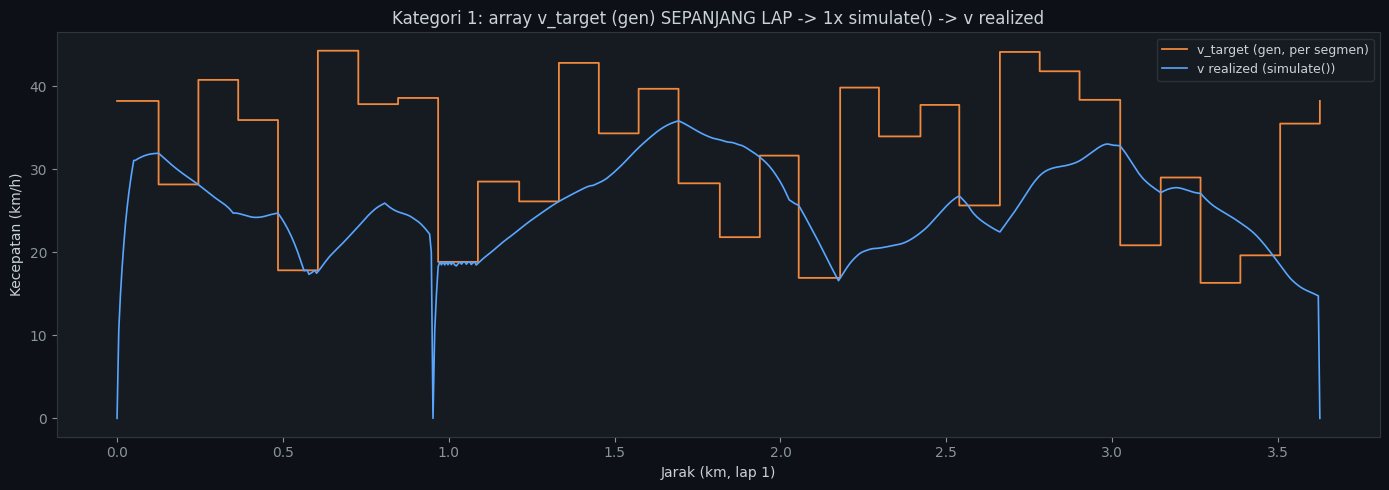

In [6]:
NUM_SEGMENTS_PER_LAP = 30
V_MIN, V_MAX = 15.0, 45.0
lap_distance_km = profile_1lap["distance_km"].iloc[-1]

rng = np.random.default_rng(42)
v_target_genes = rng.uniform(V_MIN, V_MAX, NUM_SEGMENTS_PER_LAP)
v_coast_genes = np.minimum(rng.uniform(V_MIN, V_MAX, NUM_SEGMENTS_PER_LAP), v_target_genes)

s_km = full_track["distance_km"].to_numpy()
segment_indices = np.floor((s_km % lap_distance_km) / (lap_distance_km / NUM_SEGMENTS_PER_LAP)).astype(int)
segment_indices = np.clip(segment_indices, 0, NUM_SEGMENTS_PER_LAP - 1)
v_target_kmh = v_target_genes[segment_indices]
v_coast_kmh = v_coast_genes[segment_indices]

t0 = time.time()
tel_batch = sim_mod.simulate(full_track, scenario, accel_motor=accel_motor, cruise_motor=cruise_motor,
                              fc=fc, v_target_kmh=v_target_kmh, v_coast_kmh=v_coast_kmh,
                              motor_select_mode="rule")
elapsed = time.time() - t0

dist_km = tel_batch["distance_km"].iloc[-1]
h2_m3 = tel_batch["h2_cumulative_m3"].iloc[-1]
acc_j = tel_batch["accessory_energy_cumulative_j"].iloc[-1]
score = telemetry_mod.h2_score_km_per_m3(dist_km, h2_m3, accessory_energy_j=acc_j)
print(f"1 panggilan simulate() untuk 1 kandidat (gen ACAK, bukan hasil optimasi): {elapsed:.2f} s")
print(f"  skor={score:.1f} km/m^3 | H2={h2_m3*1000:.2f} L | waktu={tel_batch['t_s'].iloc[-1]/60:.2f} min")
print("  (skor acak ini jelek dibanding hasil GA asli di SEM_Digital_Twin_Demo.ipynb -- wajar,")
print("   gen di sini benar-benar acak, bukan produk 30+ generasi evolusi)")

fig, ax = plt.subplots(figsize=(14, 5))
lap1 = tel_batch[tel_batch["lap"] == 1]
ax.step(lap1["distance_km"], v_target_kmh[:len(lap1)], where="post", color="#f0883e",
        linewidth=1.3, label="v_target (gen, per segmen)")
ax.plot(lap1["distance_km"], lap1["v_kmh"], color="#58a6ff", linewidth=1.2, label="v realized (simulate())")
ax.set_xlabel("Jarak (km, lap 1)")
ax.set_ylabel("Kecepatan (km/h)")
ax.set_title("Kategori 1: array v_target (gen) SEPANJANG LAP -> 1x simulate() -> v realized")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("assets/plot_ctrl_batch_example.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

## 4. Kategori 2 -- Grid Dynamic Programming (DP), Tanpa `simulate.py` Sama Sekali

`optimize_dp.py` **tidak pernah** memanggil `simulate.simulate()` atau `simulate.step()` untuk solve
intinya (dikonfirmasi langsung dari import-nya: `sim_mod` cuma dipakai untuk `build_full_attempt_track()`
menyiapkan track, bukan untuk fisika). Alasannya murni performa: backward induction DP butuh mengevaluasi
transisi dari SETIAP sel `(jarak, kecepatan)` grid ke SETIAP sel berikutnya yang mungkin -- ribuan hingga
puluhan ribu transisi -- jauh terlalu banyak untuk masing-masing jadi satu panggilan `simulate()` yang
mahal. Solusinya: `build_h2_flow_lookup()` menghitung ulang formula `vehicle.py`/`powertrain.py` yang
SAMA (drag/roll/grade/cornering -> traksi -> daya motor -> H2) langsung sebagai tabel lookup 2D
(kecepatan x daya), lalu backward induction tinggal INDEX ke tabel itu, bukan mengintegrasikan fisika
per transisi.

Grid DP: 1451 titik (di-resample dari 2936 titik simulate(), ds lebih kasar)
Lookup table H2: 400 titik (daya roda -> aliran H2), dipakai SEBAGAI GANTI memanggil simulate()
  daya roda maks tercakup: 1599 W


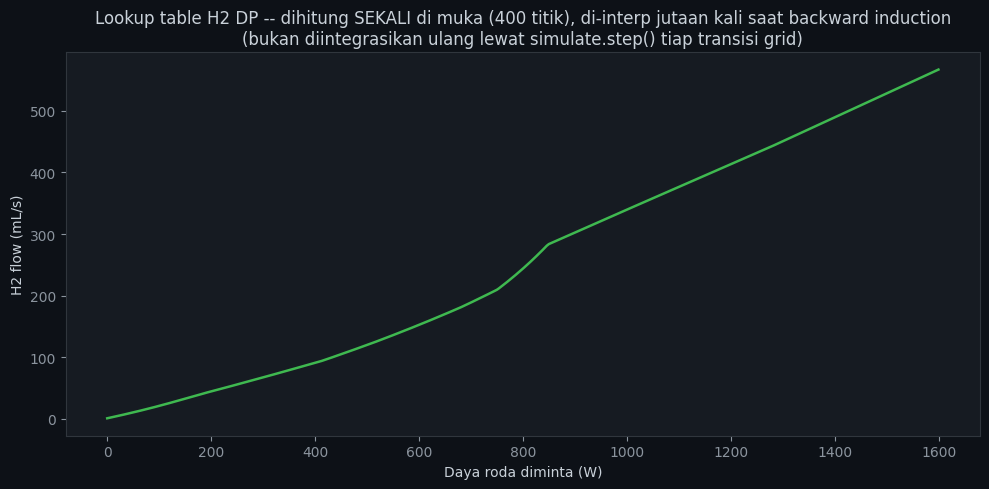


Perkiraan jumlah transisi dievaluasi DP: skala ~1,451 titik jarak x 61x61 pasangan kecepatan
Kalau tiap transisi itu 1 panggilan simulate() (perlu detik per panggilan untuk 1 LAP PENUH),
DP tidak akan pernah selesai dalam waktu wajar -- makanya ia PUNYA jalur fisika sendiri (lookup 1D + np.interp).


In [7]:
track_grid = optimize_dp.resample_track(full_track)
print(f"Grid DP: {len(track_grid)} titik (di-resample dari {len(full_track)} titik simulate(), ds lebih kasar)")

p_wheel_grid, h2_flow_grid, p_wheel_max = optimize_dp.build_h2_flow_lookup(motors[config.DEFAULT_MOTOR_NAME], fc)
print(f"Lookup table H2: {len(p_wheel_grid)} titik (daya roda -> aliran H2), dipakai SEBAGAI GANTI memanggil simulate()")
print(f"  daya roda maks tercakup: {p_wheel_max:.0f} W")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(p_wheel_grid, h2_flow_grid * 1e6, color="#3fb950", linewidth=1.8)
ax.set_xlabel("Daya roda diminta (W)")
ax.set_ylabel("H2 flow (mL/s)")
ax.set_title("Lookup table H2 DP -- dihitung SEKALI di muka (400 titik), di-interp jutaan kali saat backward induction\n"
             "(bukan diintegrasikan ulang lewat simulate.step() tiap transisi grid)")
plt.tight_layout()
plt.savefig("assets/plot_ctrl_dp_lookup.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()

n_v_bins = optimize_dp.N_V_BINS  # DP's own velocity grid resolution (solve_dp's v_grid)
n_transitions_est = len(track_grid) * n_v_bins * n_v_bins
print(f"\nPerkiraan jumlah transisi dievaluasi DP: skala ~{len(track_grid):,} titik jarak x {n_v_bins}x{n_v_bins} pasangan kecepatan")
print("Kalau tiap transisi itu 1 panggilan simulate() (perlu detik per panggilan untuk 1 LAP PENUH),")
print("DP tidak akan pernah selesai dalam waktu wajar -- makanya ia PUNYA jalur fisika sendiri (lookup 1D + np.interp).")

## 5. Kategori 3 -- Receding-Horizon (MPC), `step()` Berkali-kali per Satu Keputusan

`MPCController.solve_step(i, v0_ms, ...)` dipanggil di SATU titik nyata `i`. Di dalamnya:

1. Bangun `n_candidates` kecepatan kandidat (linspace antara lantai/langit-langit kecepatan).
2. Untuk **SETIAP** kandidat, `_rollout_cost()` memanggil `simulate.step()` sebanyak `horizon_n` kali
   berturut-turut (default 20-25 langkah ke depan) -- ini HIPOTETIS, tidak benar-benar terjadi, cuma
   "kalau saya kejar kecepatan ini, apa yang terjadi 20 langkah ke depan?".
3. Pilih kandidat dengan biaya (H2 + waktu + keselamatan + kehalusan) terendah.
4. Baru SEKALI lagi panggil `simulate.step()` -- kali ini BENAR-BENAR melangkah satu langkah nyata.
5. `i` maju satu, ULANGI SELURUH PROSES dari langkah 1 -- horizon-nya "geser" (receding), bukan
   direncanakan sekali di awal seperti Kategori 1.

Ini yang membuat MPC disebut *adaptive*: setiap keputusan dihitung ulang dari kondisi NYATA saat itu
(termasuk kecepatan aktual driver kalau dipanggil live lewat `recommend()` -- persis mekanisme yang
dipakai Stratelm-GUI's driver advisory), bukan mengeksekusi rencana yang sudah dibekukan di awal.

Visualisasi di bawah membongkar langkah 1-3 di ATAS SECARA HARFIAH: menjalankan ulang persis logika
`_rollout_cost()` tapi MEREKAM lintasan kecepatan tiap kandidat (bukan cuma biaya akhirnya), supaya
"kandidat masa depan yang dibayangkan MPC" benar-benar kelihatan sebagai garis-garis di grafik.

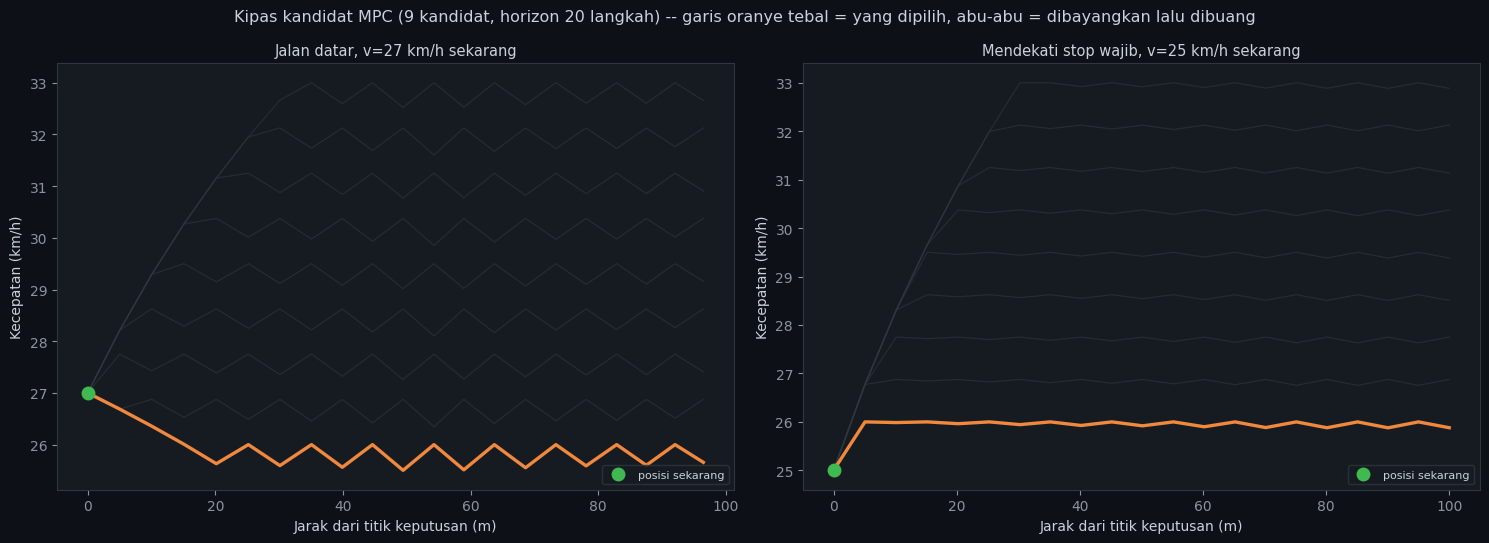

Panel kiri: dipilih 26.0 km/h (tracking) | Panel kanan: dipilih 26.0 km/h (tracking)
Catatan: garis oranye BERGERIGI itu asli, bukan artefak plot -- itulah pulse-and-glide
(gas menuju v_cmd, lalu motor mati/glide begitu tercapai, lalu gas lagi begitu turun --
lihat komentar _rollout_cost() di mpc.py, mekanisme yang sama persis dipakai di sini).


In [8]:
def rollout_trajectory(controller, i, v_cmd_ms, v0_ms):
    # Salinan PERSIS _rollout_cost()'s inner loop, kecuali di sini merekam v di
    # setiap k alih-alih cuma mengakumulasi biaya -- supaya lintasannya bisa digambar.
    # Memanggil simulate.step() yang sama, tidak ada fisika baru di sini.
    end = min(i + controller.theta["horizon_n"], controller.n - 1)
    v = v0_ms
    s_traj = [controller.s_m[i]]
    v_traj = [v0_ms * 3.6]
    for k in range(i, end):
        ds = controller.ds[k]
        v_ceil = controller.ceiling_ms[k + 1]
        a_safety = (v_ceil ** 2 - v ** 2) / (2 * ds) if ds > 0 else 0.0
        if v_cmd_ms > v:
            v_gas = min(v_cmd_ms, v_ceil)
            a_des = (v_gas ** 2 - v ** 2) / (2 * ds) if ds > 0 else 0.0
            glide = False
        else:
            a_des, glide = a_safety, True
        res = sim_mod.step(v, ds, controller.grade[k], controller.heading[k], controller.r_min[k],
                           a_des, controller.scenario, controller.motor, controller.fc,
                           accel_motor=controller.accel_motor, cruise_motor=controller.cruise_motor,
                           motor_select_mode=controller.motor_select_mode,
                           relaunching=bool(controller.stop_event[k]), glide=glide)
        v = res.v_next
        s_traj.append(controller.s_m[k + 1])
        v_traj.append(v * 3.6)
    return np.array(s_traj), np.array(v_traj)


controller = mpc_mod.MPCController(full_track, scenario, None, fc, theta=mpc_mod.BEST_THETA,
                                   n_candidates=mpc_mod.BEST_N_CANDIDATES,
                                   accel_motor=accel_motor, cruise_motor=cruise_motor,
                                   motor_select_mode=config.MOTOR_SELECT_MODE_DEFAULT)

def plot_candidate_fan(ax, controller, i, v0_kmh, title):
    v0_ms = v0_kmh / 3.6
    v_ceil = controller.ceiling_ms[min(i + 1, controller.n - 1)]
    v_hi = min(controller.v_max_ms, v_ceil)
    v_lo = min(controller.v_min_ms, v_hi)
    candidates = np.linspace(v_lo, v_hi, controller.n_candidates)

    driver_state = {"a_actual_ms2": 0.0, "deviation_ms": 0.0, "deviation_cumsum_ms": 0.0,
                    "throttle_pct": 0.0, "brake_pct": 0.0}
    best_cmd, v_corr, mode = controller.solve_step(i, v0_ms, driver_state, v0_ms)

    for vc in candidates:
        s_traj, v_traj = rollout_trajectory(controller, i, float(vc), v0_ms)
        is_chosen = abs(vc - best_cmd) < 1e-6
        ax.plot((s_traj - s_traj[0]), v_traj,
                color="#f0883e" if is_chosen else "#30363d",
                linewidth=2.4 if is_chosen else 0.9, alpha=1.0 if is_chosen else 0.6, zorder=5 if is_chosen else 2)
    ax.plot(0, v0_kmh, "o", color="#3fb950", markersize=9, zorder=6, label="posisi sekarang")
    ax.set_xlabel("Jarak dari titik keputusan (m)")
    ax.set_ylabel("Kecepatan (km/h)")
    ax.set_title(title, fontsize=10.5)
    ax.legend(fontsize=8, loc="lower right")
    return best_cmd, mode

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
i_flat = int(np.searchsorted(controller.s_m, 500.0))
best1, mode1 = plot_candidate_fan(axes[0], controller, i_flat, 27.0, "Jalan datar, v=27 km/h sekarang")

stop_idx = np.where(controller.stop_event)[0]
i_near_stop = max(0, stop_idx[stop_idx > 200][0] - 400) if len(stop_idx[stop_idx > 200]) else i_flat
best2, mode2 = plot_candidate_fan(axes[1], controller, i_near_stop, 25.0, "Mendekati stop wajib, v=25 km/h sekarang")

fig.suptitle(f"Kipas kandidat MPC ({controller.n_candidates} kandidat, horizon {controller.theta['horizon_n']} langkah) --"
             " garis oranye tebal = yang dipilih, abu-abu = dibayangkan lalu dibuang", fontsize=11.5)
plt.tight_layout()
plt.savefig("assets/plot_ctrl_mpc_fan.png", dpi=150, bbox_inches="tight", facecolor="#0d1117")
plt.show()
print(f"Panel kiri: dipilih {best1*3.6:.1f} km/h ({mode1}) | Panel kanan: dipilih {best2*3.6:.1f} km/h ({mode2})")
print("Catatan: garis oranye BERGERIGI itu asli, bukan artefak plot -- itulah pulse-and-glide")
print("(gas menuju v_cmd, lalu motor mati/glide begitu tercapai, lalu gas lagi begitu turun --")
print("lihat komentar _rollout_cost() di mpc.py, mekanisme yang sama persis dipakai di sini).")

## 6. Berapa Kali Masing-Masing Benar-Benar Memanggil Simulator?

Perbedaan pola ini bukan cuma gaya penulisan kode -- ia langsung menentukan berapa lama masing-masing
BUTUH WAKTU untuk sekali jalan, dan itulah yang mendikte desain arsitektur di atasnya (mengapa GA/PSO/
CMA-ES perlu populasi kecil + generasi terbatas, kenapa DP tidak bisa memakai `simulate()` biasa, dan
kenapa MPC harus murah PER-LANGKAH karena dipanggil begitu sering).

In [9]:
t0 = time.time()
_ = sim_mod.simulate(full_track, scenario, accel_motor=accel_motor, cruise_motor=cruise_motor, fc=fc,
                      v_target_kmh=v_target_kmh, v_coast_kmh=v_coast_kmh, motor_select_mode="rule")
t_simulate = time.time() - t0

t0 = time.time()
_ = sim_mod.step(v0_ms=8.0, ds=1.0, grade_pct=0.5, heading_deg=45.0, r_min_m=100.0,
                 a_des=0.2, scenario=scenario, motor=None, fc=fc,
                 accel_motor=accel_motor, cruise_motor=cruise_motor, motor_select_mode="rule")
t_step = (time.time() - t0)

n_candidates, horizon_n = mpc_mod.BEST_N_CANDIDATES, mpc_mod.BEST_THETA["horizon_n"]
step_calls_per_real_decision = n_candidates * horizon_n + 1
n_real_steps_full_attempt = len(full_track)

rows = [
    {"kategori": "1. Batch (GA/PSO/CMA/Fuzzy)", "panggilan per evaluasi": "1x simulate()",
     "perkiraan waktu 1 evaluasi": f"{t_simulate:.2f} s",
     "catatan": "GA pop=50 x gen=40 = 2000 evaluasi -> berjam-jam; makanya populasi/generasi dibatasi"},
    {"kategori": "2. DP (grid, tanpa simulate())", "panggilan per evaluasi": "0x simulate(), lookup table sendiri",
     "perkiraan waktu 1 evaluasi": "n/a (index tabel, bukan integrasi)",
     "catatan": f"~{len(track_grid)*n_v_bins*n_v_bins:,} transisi grid -- mustahil lewat simulate() satu-satu"},
    {"kategori": "3. MPC (receding horizon)", "panggilan per evaluasi": f"{step_calls_per_real_decision}x step() PER langkah nyata",
     "perkiraan waktu 1 evaluasi": f"{t_step*1000:.2f} ms/step() x {step_calls_per_real_decision} = {t_step*step_calls_per_real_decision*1000:.1f} ms/keputusan",
     "catatan": f"x {n_real_steps_full_attempt:,} langkah nyata sepanjang attempt = alasan step() HARUS jauh lebih murah dari simulate()"},
]
pd.DataFrame(rows).set_index("kategori")

,panggilan per evaluasi,perkiraan waktu 1 evaluasi,catatan
kategori,,,
1. Batch (GA/PSO/CMA/Fuzzy),1x simulate(),0.68 s,GA pop=50 x gen=40 = 2000 evaluasi -> berjam-j...
"2. DP (grid, tanpa simulate())","0x simulate(), lookup table sendiri","n/a (index tabel, bukan integrasi)","~5,399,171 transisi grid -- mustahil lewat sim..."
3. MPC (receding horizon),181x step() PER langkah nyata,0.00 ms/step() x 181 = 0.0 ms/keputusan,"x 2,936 langkah nyata sepanjang attempt = alas..."


## 7. Ringkasan

Tidak ada satu "cara standar" controller berbicara ke `simulate.py` -- tiga pola yang benar-benar
berbeda, dipilih sesuai kebutuhan komputasi masing-masing algoritma:

| Kategori | Algoritma | Pintu masuk | Kapan rencana diputuskan |
|---|---|---|---|
| Batch | GA, PSO, CMA-ES, Fuzzy | `simulate()`, 1x per kandidat | SEKALI, sebelum simulasi berjalan (di muka) |
| Grid DP | DP | tidak ada -- lookup table sendiri | via backward induction, tidak lewat `simulate.py` |
| Receding-horizon | MPC | `step()`, N x horizon_n kali per keputusan nyata | DIULANG setiap satu langkah nyata (adaptif) |

**Kenapa ini penting di luar sekadar arsitektur kode:** pola receding-horizon MPC adalah SATU-SATUNYA
yang genuinely bereaksi ke kondisi NYATA saat itu (posisi & kecepatan aktual, lewat `recommend()`) --
inilah yang dipakai Stratelm-GUI's driver-advisory bridge untuk memberi saran ke driver sungguhan
secara live. Ketiga lainnya (GA/PSO/CMA/Fuzzy/DP) menghasilkan SATU rencana yang dibekukan sebelum
attempt dimulai -- kalau driver menyimpang dari rencana itu di tengah jalan, mereka tidak tahu dan tidak
bisa menyesuaikan; hanya `dp_policy.py`'s precomputed lookup (dibangun dari solusi DP) dan MPC's
`recommend()` yang bisa menjawab "dari POSISI SEBENARNYA saya sekarang, apa yang harus saya lakukan" --
bukan cuma "apa yang seharusnya terjadi di titik ini menurut rencana awal".